# Used Cars Dataset
## Ссылка на датасет: https://www.kaggle.com/datasets/taeefnajib/used-car-price-prediction-dataset
Данный датасет выбран по причине личного интереса к автомобильной индустрии, и использовался для решения задачи по предсказанию цены подержанного автомобиля. В ходе исследования датасета было предложено несколько гипотез:

- При кодировании признака 'brand' стоит выбирать не более чем топ-7 категорий для OneHotEncoder (число категорий может подбираться как гиперпараметр). В противном случае OHE приведет к переобучению.
- Линейная модель регрессии будет справляться не хуже, чем дерево решений, поскольку количество данных небольшое (~4000).
- Наиболее важными признаками дерева будут 'milage', 'model_year' и 'accident'.
- Для линейной модели L2 регуляризация будет работать лучше, чем L1, поскольку количество признаков в выборке небольшое, а шумовые удаляются на этапе EDA.
- CatBoost даст наилучший результат ввиду самого алгоритма работы "из коробки" с категориальными признаками.

## 1. Загрузка данных

In [389]:
import pandas as pd
import kagglehub

path = kagglehub.dataset_download("taeefnajib/used-car-price-prediction-dataset")

df = pd.read_csv(fr'{path}\used_cars.csv')

df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 892.6 KB


(4009, 12)

In [390]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


## 2. EDA

In [391]:
# Очистка признаков price, milage

df = df.convert_dtypes()

df['milage'] = df['milage'].str.replace(r'\D', '', regex=True).astype('int64')

df['price'] = df['price'].str.replace(r'\D', '', regex=True).astype('int64')

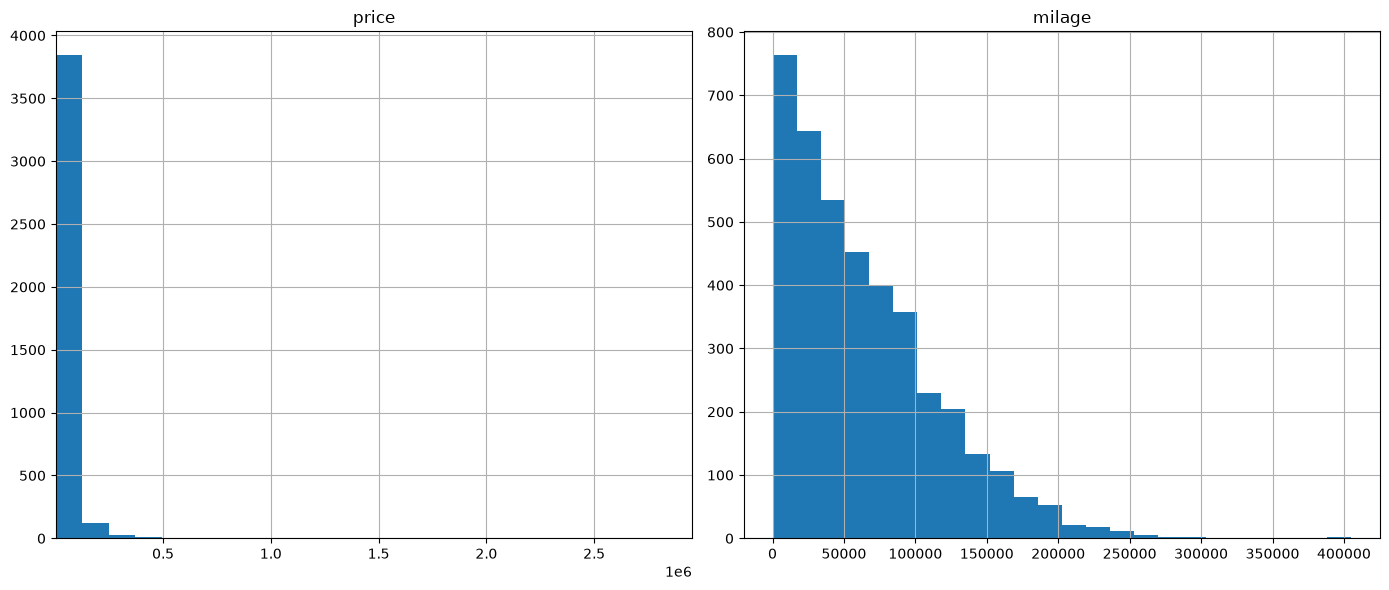

In [392]:
# Распределение числовых признаков milage, price

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

df['price'].hist(bins=24, ax=ax[0])
ax[0].set_title('price')
ax[0].set_xlim(df['price'].min(), df['price'].max())

df['milage'].hist(bins=24, ax=ax[1])
ax[1].set_title('milage')

plt.tight_layout()
plt.show()

По построенным диаграммам можно сделать вывод, что цена распределена очень неравномерно, следовательно, в качестве гипотезы, к целевому признаку (цене) можно применить логарифм для более равномерного распределения, близкого к нормальному.

На основе датасета можно сделать вывод, что признаки model, engine, transmission, ext_col, int_col обладают **высокой кардинальностью** (очень много уникальных категорий признака), поэтому на этапе предобработки уберем их из датасета.

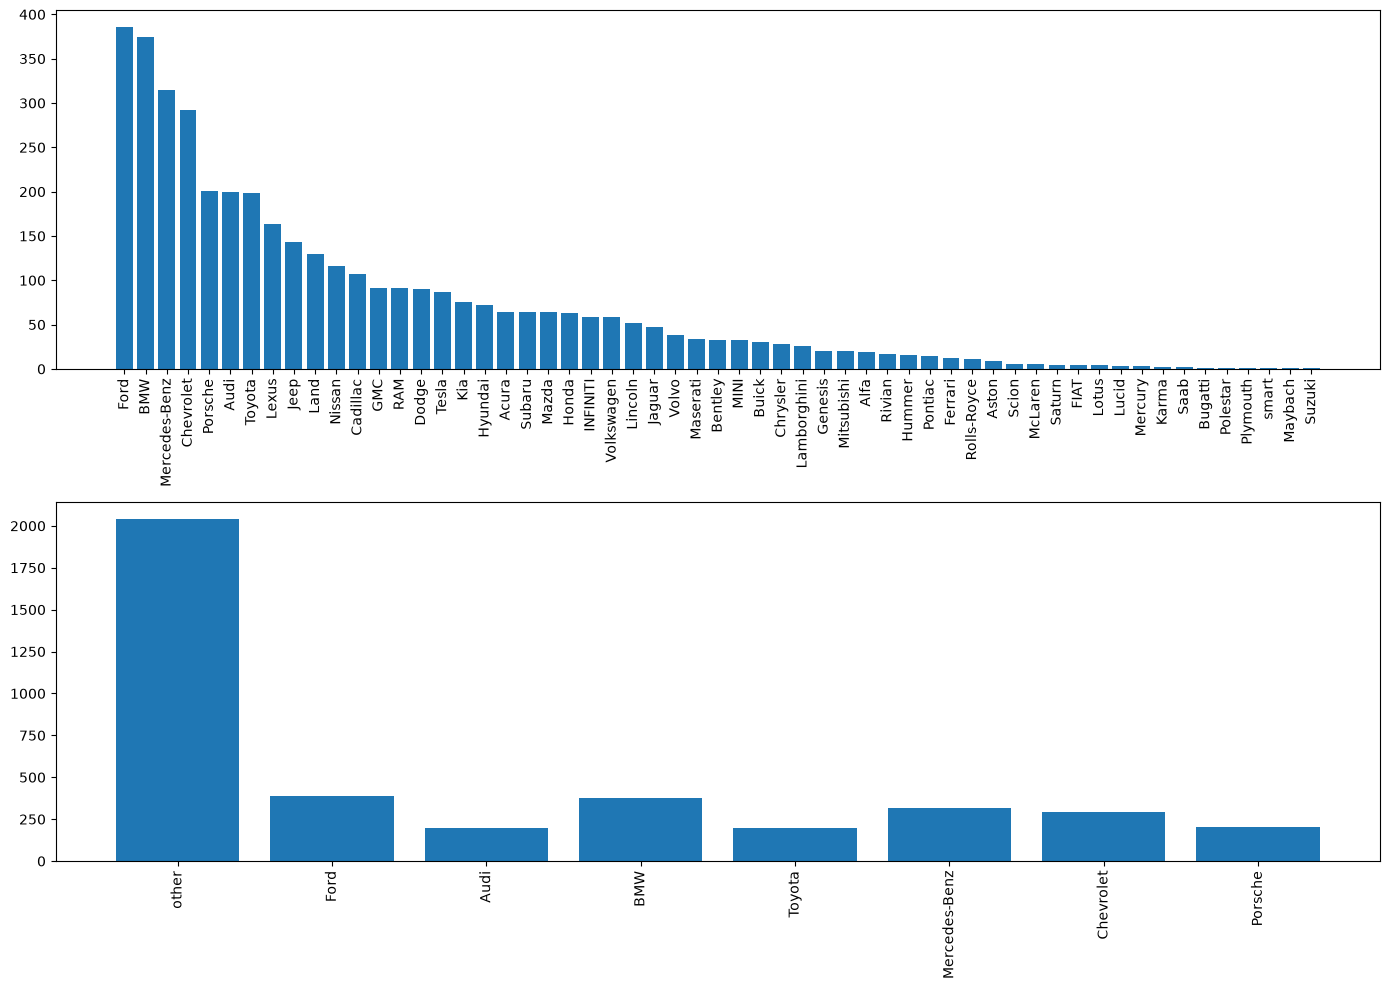

In [393]:
# Выделим категориальные признаки, которые в дальнейшем будем использовать, и проанализируем их.

cat_features = ['brand', 'fuel_type', 'accident', 'clean_title'] 

# Рассмотрим признак brand
brand_counts = df['brand'].value_counts()
top_brands = {'other': 0}

for brand in df['brand'].unique():
    if brand_counts[brand] / len(df) > 0.045:
        top_brands[brand] = brand_counts[brand]
    else: 
        top_brands['other'] += brand_counts[brand]


fig, ax = plt.subplots(2, 1, figsize=(14, 10))
ax[1].bar(top_brands.keys(), top_brands.values())
ax[1].tick_params(axis="x", labelrotation=90)

ax[0].bar(brand_counts.index, brand_counts.tolist())
ax[0].tick_params(axis="x", labelrotation=90)
plt.tight_layout()
plt.show()

По распределению брендов можно сделать предположение, что для качественной работы модели требуется определять всего 8 категорий марок: топ-7 марок по численности в датасете, и все остальные.

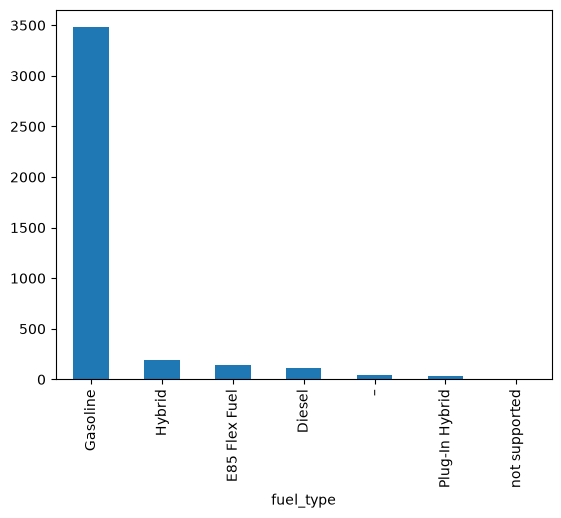

In [394]:
# fuel_type

df['fuel_type'] = df['fuel_type'].fillna('Gasoline')

fig, ax = plt.subplots()
df['fuel_type'].value_counts().plot.bar(ax=ax)
plt.show()

По распределению типов топлива сделаем предположение, что будет достаточно определить 5 категорий: топ-4 по численности, и остальные.

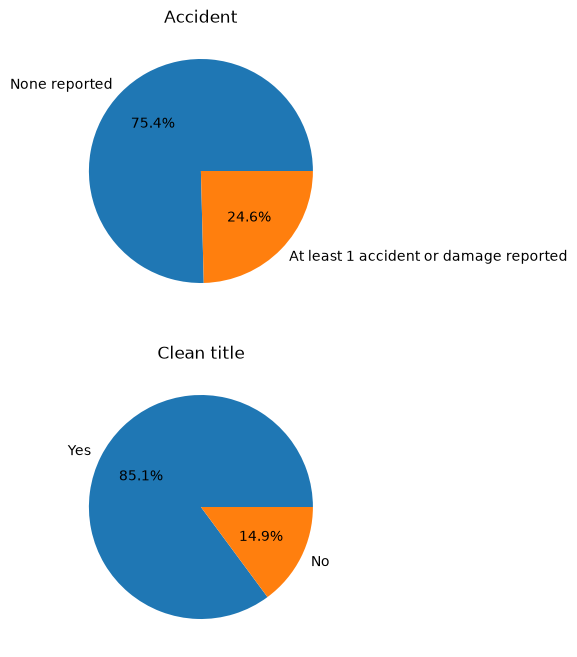

In [395]:
# accident, clean_title

df['accident'] = df['accident'].fillna('None reported')
df['clean_title'] = df['clean_title'].fillna('No')

fig, ax = plt.subplots(2, 1, figsize=(5, 8))

df['accident'].value_counts().plot.pie(ax=ax[0], autopct='%1.1f%%')
ax[0].set_title('Accident')

df['clean_title'].value_counts().plot.pie(ax=ax[1], autopct='%1.1f%%',)
ax[1].set_title('Clean title')
plt.show()

## 3. Feature engineering
Очистим датасет от незначимых признаков, и прологарифмируем price. Далее, сделаем train_test_split перед кодированием признаков, чтобы избежать Data leakage. Также сформируем отдельный датасет для CatBoost, который не нуждается в дополнительной предобработке.

In [396]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


df['log_price'] = np.log1p(df['price']) # возьмем log(1 + x), дабы избежать ошибок при очень маленьком x

X = df.drop(['model', 'engine', 'transmission', 'ext_col', 'int_col', 'price', 'log_price'], axis=1)
y = df['log_price']

# создаем обучающую выборку для CatBoost
X_CB = df.drop(['price', 'log_price'], axis=1)
y_CB = df['price']


num_features = ['model_year', 'milage']
cat_features = ['brand', 'fuel_type', 'accident', 'clean_title']

X[cat_features] = X[cat_features].astype('category')


# используем ColumnTransformer, чтобы автоматизировать предобработку данных для каждого типа признаков
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('brand_ohe', OneHotEncoder(
            max_categories=8, 
            sparse_output=False, 
            handle_unknown='ignore'), ['brand']),
        ('fuel_ohe', OneHotEncoder(
            max_categories=5, 
            sparse_output=False, 
            handle_unknown='ignore'), ['fuel_type']),
        ('cat_oe', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_features[2:4])
    ]
)

x_train, x_test, y_train, y_test = train_test_split(X, y, random_state=77, test_size=0.3)

# строим пайплайн как функцию от модели
linear_pipeline = lambda model: Pipeline([
    ('preprocessor', preprocessor), 
    ('model', model)
])

## 4. Обучение baseline моделей: Ridge, Lasso, DecisionTreeRegressor
Обучаем модели и используем GridSearchCV для подбора гиперпараметров.

In [397]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error


linear_models = [Ridge(), Lasso()]
results = []
best_coefs = {}

param_grid_linear = {
    'preprocessor__brand_ohe__max_categories': [2, 4, 6, 7, 8, 10, 15, 20, 50, 57],
    'preprocessor__fuel_ohe__max_categories': [2, 3, 4, 5, 7],
    'model__alpha': [0.1, 0.01, 0.001, 0.0001, 0.00001, 0.5, 1.0, 2.0, 5.0]
}

for model in linear_models:
    grid_linear = GridSearchCV(
        linear_pipeline(model),
        param_grid_linear,
        cv=5, 
        scoring='r2',
        n_jobs=-1
    )
    
    grid_linear.fit(x_train, y_train)
    
    best_model = grid_linear.best_estimator_
    y_pred_linear = best_model.predict(x_test)
    
    linear_model = best_model.named_steps['model']    
    coefficients = linear_model.coef_
    preprocessor = best_model.named_steps['preprocessor']
    feature_names = preprocessor.get_feature_names_out()

    best_coefs[f'{str(model).translate({ord(c): None for c in "()"})}(alpha={grid_linear.best_params_['model__alpha']})'] = coefficients
    
    results.append({
        'Model': f'{str(model).translate({ord(c): None for c in "()"})}(alpha={grid_linear.best_params_['model__alpha']})',
        'RMSE': root_mean_squared_error(y_test, y_pred_linear),
        'MAE': mean_absolute_error(y_test, y_pred_linear),
        'R²': r2_score(y_test, y_pred_linear),
    })

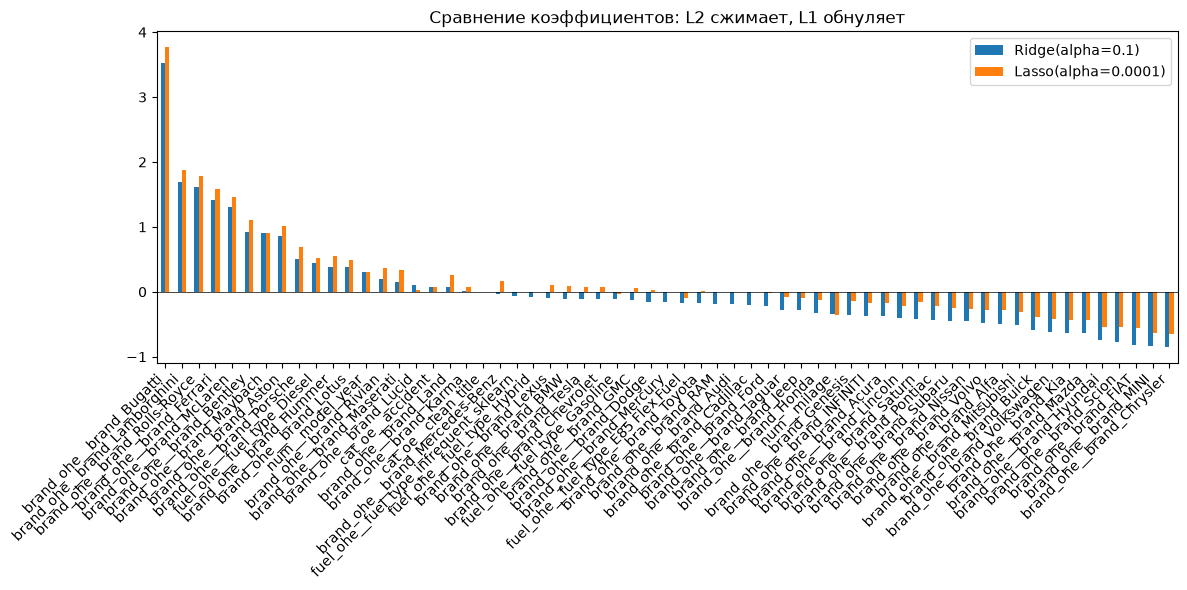

In [398]:
coefs = pd.DataFrame(best_coefs, index=feature_names)

fig, ax = plt.subplots(figsize=(12, 6))
coefs.sort_values(by=list(best_coefs.keys()), ascending=[False, False]).plot.bar(ax=ax)
ax.set_title('Сравнение коэффициентов: L2 сжимает, L1 обнуляет')
ax.axhline(0, color='black', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [399]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint


tree_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('brand_ohe', OneHotEncoder(
            max_categories=8, 
            sparse_output=False, 
            handle_unknown='ignore'), ['brand']),
        ('fuel_ohe', OneHotEncoder(
            max_categories=5, 
            sparse_output=False, 
            handle_unknown='ignore'), ['fuel_type']),
        ('cat_oe', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_features[2:4])
    ]
)

tree_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('tree', DecisionTreeRegressor(random_state=42))
])

param_grid_tree = {
    'tree__max_depth': randint(2, 50),
    'tree__min_samples_split': randint(2, 400),
    'tree__min_samples_leaf': randint(1, 200),
    'tree__criterion': ['squared_error', 'absolute_error', 'poisson'],
}

rand_search = RandomizedSearchCV(
    tree_pipeline,
    param_grid_tree, 
    n_iter=100, 
    cv=5, 
    scoring='r2', 
    random_state=42, 
    n_jobs=-1
)

rand_search.fit(x_train, y_train) 
best_tree = rand_search.best_estimator_
best_params = rand_search.best_params_

y_pred_tree = best_tree.predict(x_test)

results.append({
        'Model': f'DTR(criterion: {best_params['tree__criterion']}, max_depth: {best_params['tree__max_depth']}, min_samples_leaf: {best_params['tree__min_samples_leaf']})',
        'RMSE': root_mean_squared_error(y_test, y_pred_tree),
        'MAE': mean_absolute_error(y_test, y_pred_tree),
        'R²': r2_score(y_test, y_pred_tree),
    })

pd.DataFrame(results).set_index('Model').round(4)

,RMSE,MAE,R²
Model,,,
Ridge(alpha=0.1),0.4435,0.3306,0.7273
Lasso(alpha=0.0001),0.4426,0.3304,0.7284
"DTR(criterion: squared_error, max_depth: 37, min_samples_leaf: 13)",0.5187,0.3933,0.6269


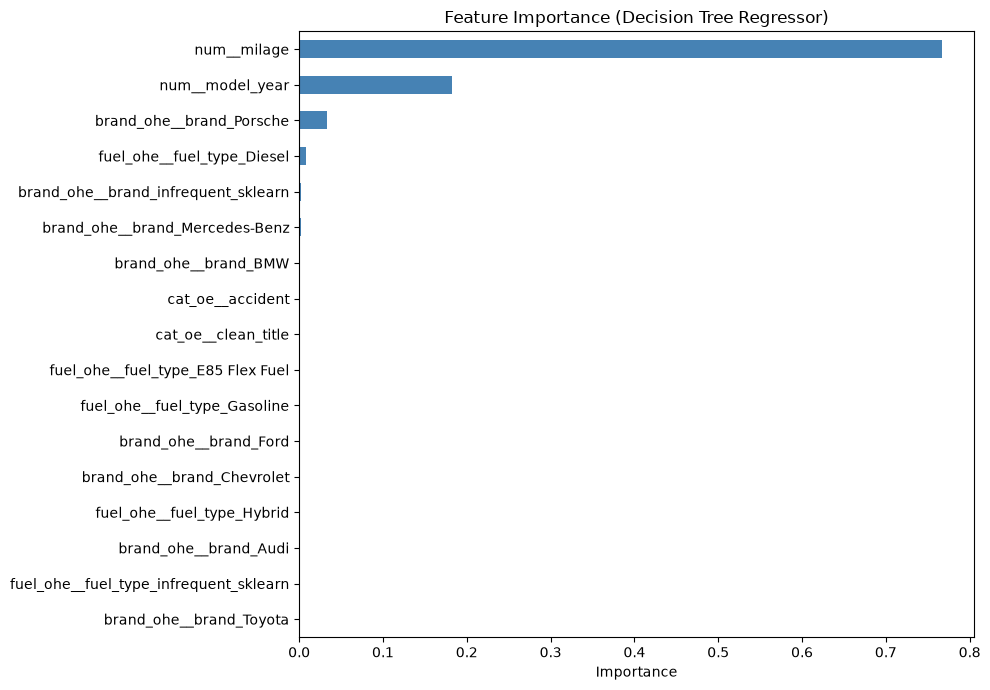

In [400]:
tree = best_tree.named_steps['tree']

preprocessor = best_tree.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()

importances = pd.Series(tree.feature_importances_, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
importances.plot.barh(ax=ax, color='steelblue')
ax.set_title('Feature Importance (Decision Tree Regressor)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()


## 5. Обучение CatBoost
- Сначала попробуем обучить на отложенном датасете, без предварительной очистки шумовых признаков, и посмотрим на результат.
- Затем обучим на датасете с очищенными признаками.

In [401]:
from catboost import CatBoostRegressor

cb = CatBoostRegressor(iterations=300, learning_rate=0.1, depth=10,
                         random_state=42, verbose=0)

# Обучаем на всех имеющихся признаках
cat_features_cb = ['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']
X_CB[cat_features_cb] = X_CB[cat_features_cb].astype('category')

x_cb_tr, x_cb_te, y_cb_tr, y_cb_te = train_test_split(X_CB, y_CB, random_state=77, test_size=0.3)

cb.fit(x_cb_tr, y_cb_tr, cat_features=cat_features_cb)
y_cb_pred = cb.predict(x_cb_te)

results.append({
        'Model': 'CatBoost (all features)',
        'RMSE': root_mean_squared_error(y_cb_te, y_cb_pred),
        'MAE': mean_absolute_error(y_cb_te, y_cb_pred),
        'R²': r2_score(y_cb_te, y_cb_pred),
    })
pd.DataFrame(results).set_index('Model').round(4)

,RMSE,MAE,R²
Model,,,
Ridge(alpha=0.1),0.4435,0.3306,0.7273
Lasso(alpha=0.0001),0.4426,0.3304,0.7284
"DTR(criterion: squared_error, max_depth: 37, min_samples_leaf: 13)",0.5187,0.3933,0.6269
CatBoost (all features),34823.1842,14484.0989,0.5403


In [402]:
# Обучаем на очищенных признаках
cb.fit(x_train, y_train, cat_features=cat_features)
y_cb_pred = cb.predict(x_test)

results.append({
        'Model': 'CatBoost (clean features)',
        'RMSE': root_mean_squared_error(y_test, y_cb_pred),
        'MAE': mean_absolute_error(y_test, y_cb_pred),
        'R²': r2_score(y_test, y_cb_pred),
    })
pd.DataFrame(results).set_index('Model').round(4)

,RMSE,MAE,R²
Model,,,
Ridge(alpha=0.1),0.4435,0.3306,0.7273
Lasso(alpha=0.0001),0.4426,0.3304,0.7284
"DTR(criterion: squared_error, max_depth: 37, min_samples_leaf: 13)",0.5187,0.3933,0.6269
CatBoost (all features),34823.1842,14484.0989,0.5403
CatBoost (clean features),0.4298,0.3268,0.7439


## 6. Выводы
После выполнения исследования сделаны следующие выводы по гипотезам:

- **Гипотеза не подтвердилась.** Данный параметр для OHE был подобран через GridSearchCV, и наиболее оптимальным значением оказались все категории 'brand', т.е. в кодировании OHE использовались все марки автомобилей. Также такой подход был применем к признаку 'fuel_type', здесь эта гипотеза оказалась более уместной: не требуется включать все категории 'fuel_type' в OHE для достижения наилучшего результата.
- **Гипотеза подтвердилась.** По предложенным метрикам RMSE, MAE и R^2, модели Ridge и Lasso показали лучшие результаты в сравнении с DecisionTreeRegressor с подобранными гиперпараметрами.
- **Гипотеза частично подтвердилась.** Согласно feature_importances для DecisionTreeRegressor наиболее важными оказались 'milage' и 'model_year', на третьем месте оказался 'brand_Porsche', что довольно необычно и трудно предсказуемо.
- **Гипотеза не подтвердилась.** Lasso с подобранными гиперпараметрами показывает чуть более хороший результат по предложенными метрикам в сравнении с Ridge.
- **Гипотеза подтвердилась.** CatBoost с очищенными признаками даёт ощутимый прирост по метрикам, при этом не требует сложной предобработки данных. При этом, если передать в CatBoost все изначальные признаки (предварительно обработанные), по метрикам он показывает наихудший результат, не сравнимый даже с DecisionTreeRegressor.